В этом блокноте Jupyter основное внимание уделяется прогнозированию того, подпишется ли клиент на срочный депозит, что является проблемой бинарной классификации. Ключевые шаги включают:
1. Загрузка и изучение данных.
2. Очистка и предварительная обработка данных, включая обработку пропущенных значений и кодирование категориальных признаков.
3. Разделение данных на обучающие, валидационные и тестовые наборы.
4. Масштабирование данных.
5. Устранение дисбаланса классов.
6. Выбор и анализ признаков.
7. Оценка модели, включая следующие ключевые показатели:
   
   а) Accuracy

   б) Recall

   в) F1 Score

Как вы увидите далее, метрики на тестовых данных меньше, чем валидационных, это хороший знак, значит у нас нет переобучения, наилучший результат у градиентного бустинга

# 0) Загрузим все необходимые библиотеки

In [2]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

from imblearn.over_sampling import RandomOverSampler
from scipy.stats import ttest_ind
from yellowbrick.classifier import DiscriminationThreshold, PrecisionRecallCurve

## 1) Загрузим данные

In [3]:
data = pd.read_csv('bank.csv', sep=';')
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [4]:
#Изменим имя целевой переменной для удобства
data.rename(columns={'y': 'term_deposit'}, inplace=True)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           4521 non-null   int64 
 1   job           4521 non-null   object
 2   marital       4521 non-null   object
 3   education     4521 non-null   object
 4   default       4521 non-null   object
 5   balance       4521 non-null   int64 
 6   housing       4521 non-null   object
 7   loan          4521 non-null   object
 8   contact       4521 non-null   object
 9   day           4521 non-null   int64 
 10  month         4521 non-null   object
 11  duration      4521 non-null   int64 
 12  campaign      4521 non-null   int64 
 13  pdays         4521 non-null   int64 
 14  previous      4521 non-null   int64 
 15  poutcome      4521 non-null   object
 16  term_deposit  4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [6]:
# Конвертируем целевую переменную в числовой бинарный формат
data['term_deposit'] = data['term_deposit'].apply(lambda x: 1 if x == 'yes' else 0)

In [7]:
# Разделим категариальные и числовые фичи
categorical_features = data.select_dtypes(include=['object']).columns.tolist()
numerical_features = data.select_dtypes(include=['int', 'float']).columns.tolist()

# 2) Очистка данных

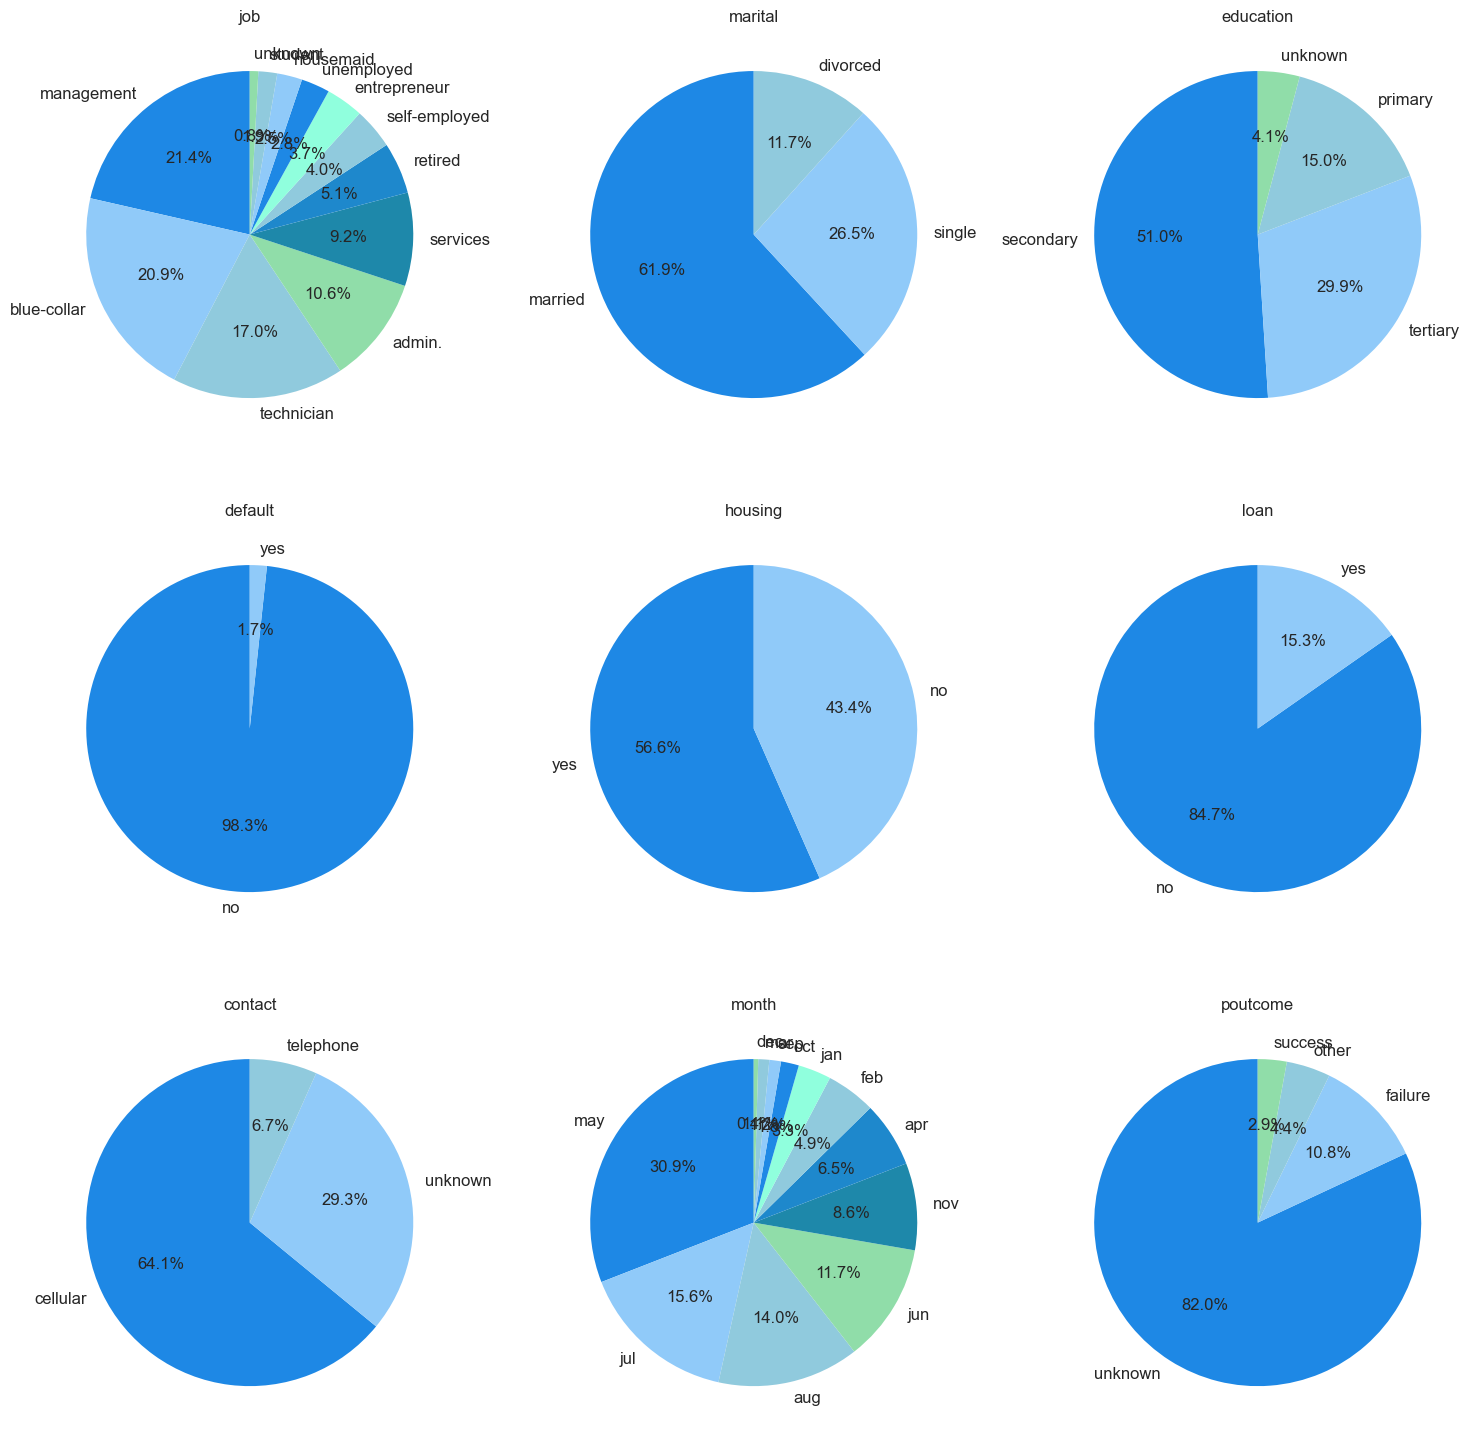

In [8]:
colors = ['#1E88E5', '#90CAF9', '#90CADD', '#90DDA9', '#1E88AA', '#1E88CC', '#90CADD', '#90FFDD']

# Посмотрим на распределение категариальных фичей используя круговые диаграммы и проверим наличие 'unknown' значений.
cols = 3
rows = 3

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    data[feature].value_counts().plot(
        kind='pie', 
        autopct='%1.1f%%', 
        colors=colors,
        startangle=90,
        textprops={'fontsize': 12},
        ax=axes[i]
    )
    axes[i].set_title(f'{feature}')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

C:\Users\Grengald\AppData\Local\Temp\ipykernel_15168\2469905677.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


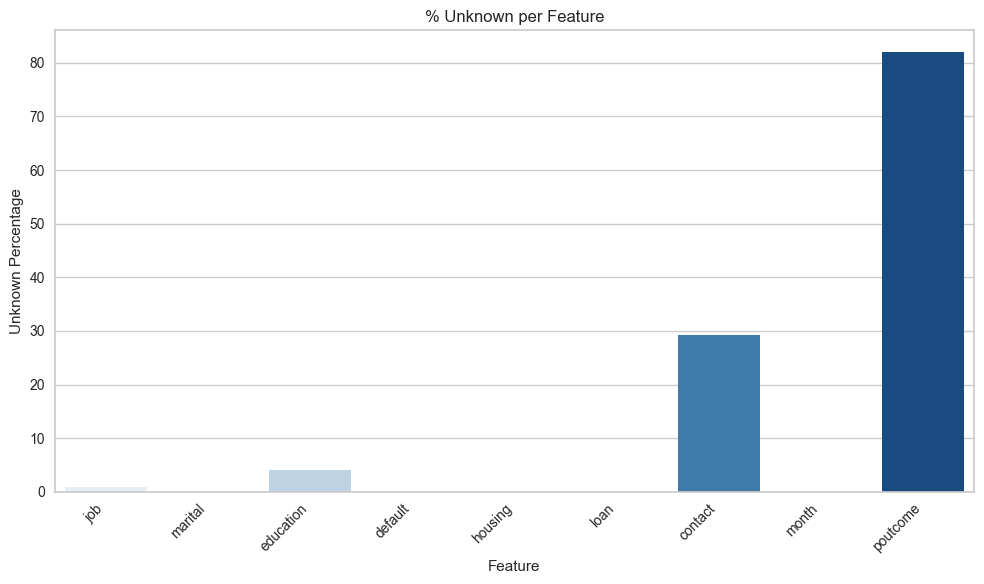

In [9]:
unknown_percentages = {}

# Проитерируемся по каждому фичу
for feature in categorical_features:
    unknown_count = data[feature].value_counts().get('unknown', 0)
    total_count = len(data[feature])
    percentage = (unknown_count / total_count) * 100
    unknown_percentages[feature] = percentage

# Конвертируем словарь в DataFrame для удобства
unknown_df = pd.DataFrame(list(unknown_percentages.items()), columns=['Feature', 'Unknown Percentage'])

plt.figure(figsize=(10, 6))
sns.barplot(
    data=unknown_df,
    x='Feature',
    y='Unknown Percentage',
    palette='Blues'
)
plt.title('% Unknown per Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [10]:
# Удалим фичи 'contact' и 'poutcome', поскольку в них высокий процент 'unknown' значений.
data.drop(columns=['contact', 'poutcome'], inplace=True)

In [11]:
# Отфильтруем строки, в которых столбцы 'education' или 'job' не равны 'unknown'
data = data[data['education'] != 'unknown']
data = data[data['job'] != 'unknown']

In [12]:
# Переведём категориальные фичи в числовой формат
label_encoders = {}
categorical_features = data.select_dtypes(include=['object']).columns.tolist()

data_encoded = data.copy()

for col in categorical_features:
    le = LabelEncoder()
    data_encoded[col] = le.fit_transform(data[col])
    label_encoders[col] = le  
    
data_encoded.head()

,age,job,marital,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,term_deposit
0,30,10,1,0,0,1787,0,0,19,10,79,1,-1,0,0
1,33,7,1,1,0,4789,1,1,11,8,220,1,339,4,0
2,35,4,2,2,0,1350,1,0,16,0,185,1,330,1,0
3,30,4,1,2,0,1476,1,1,3,6,199,4,-1,0,0
4,59,1,1,1,0,0,1,0,5,8,226,1,-1,0,0


# 3) Проведём развёрнутый анализ данных

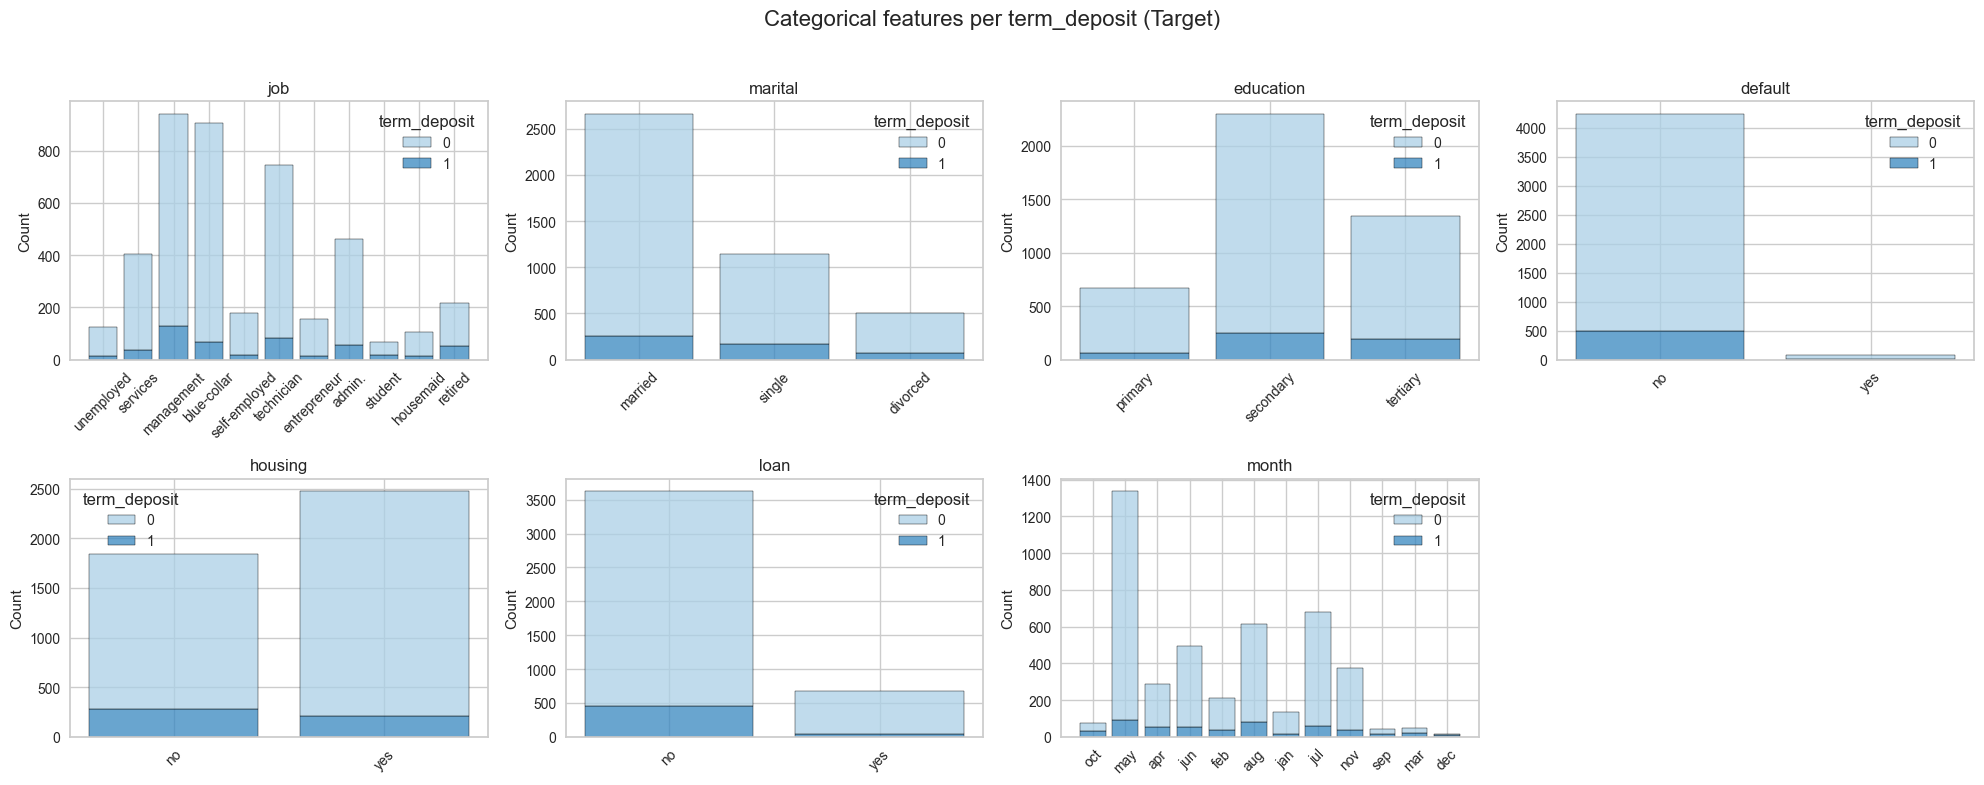

In [13]:
# Посмотрим на рапределение целевой переменной относительно категориальных фичей
cols = 4
rows = -(-len(categorical_features) // cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sns.histplot(
        data=data,
        x=feature,
        hue='term_deposit',
        multiple='stack',
        palette='Blues',
        ax=axes[i],
        shrink=0.8
    )
    axes[i].set_title(f'{feature}')
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Categorical features per term_deposit (Target)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

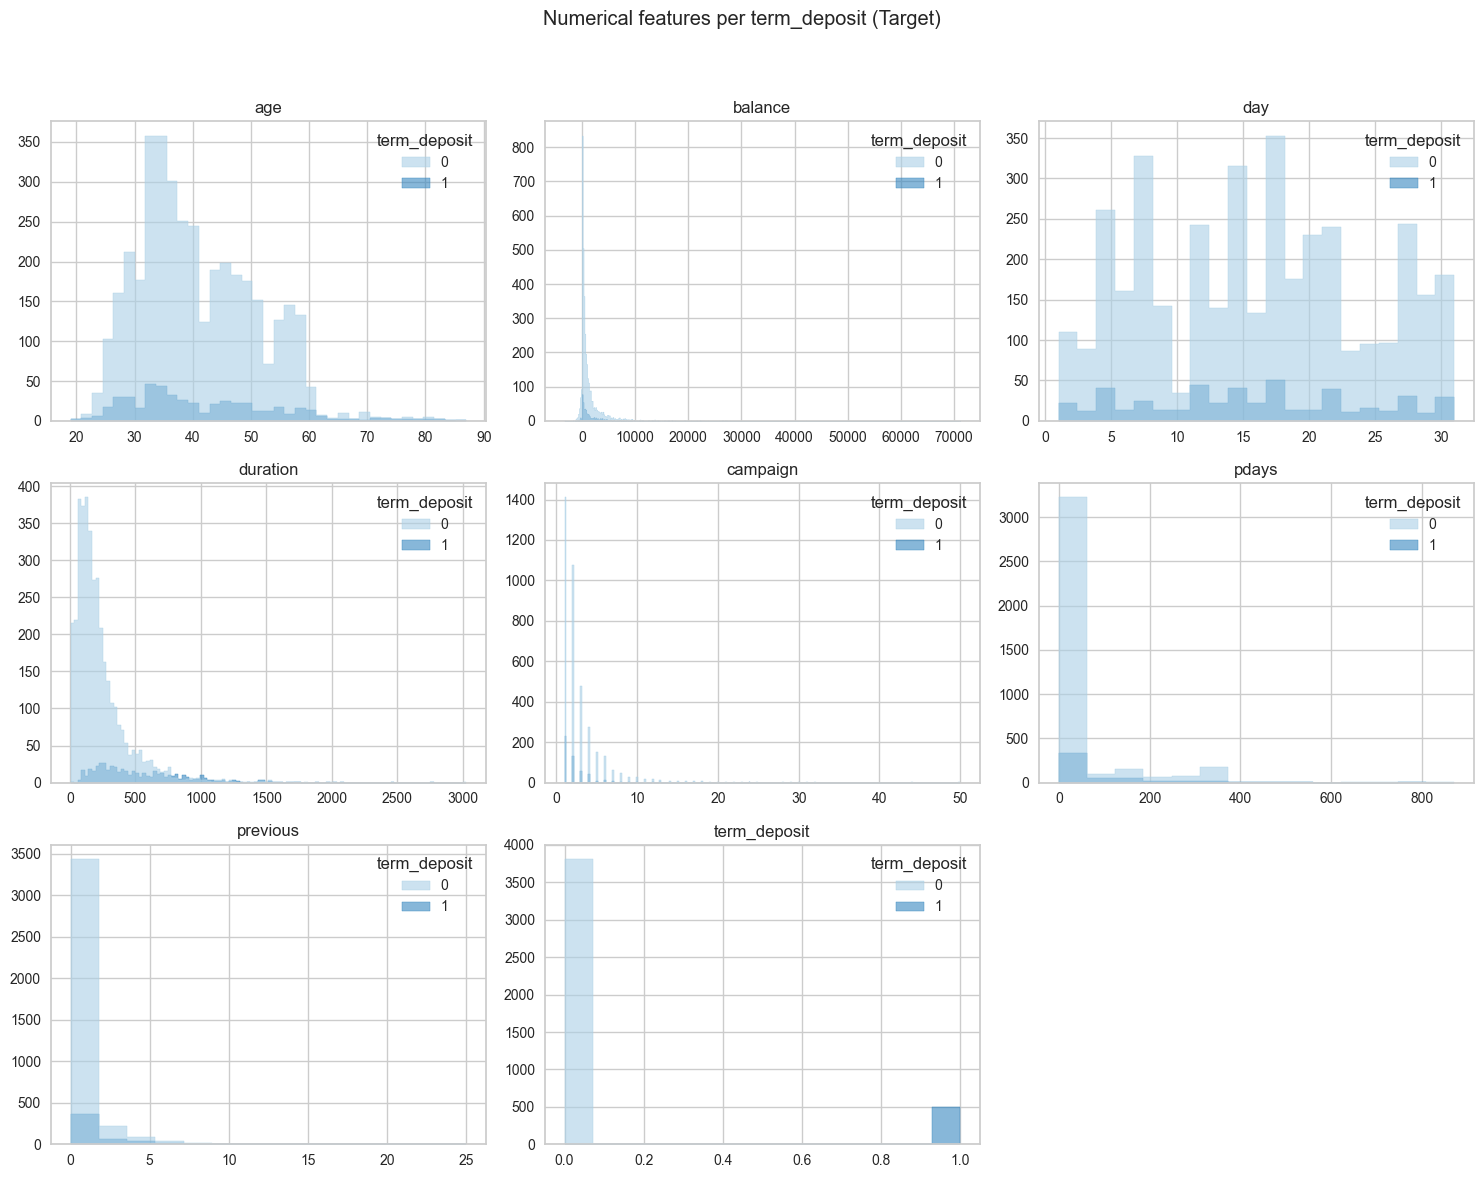

In [14]:
# Посмотрим на рапределение целевой переменной относительно числовых фичей
cols = 3
rows = -(-len(numerical_features) // cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(
        data=data,
        x=feature,
        hue='term_deposit',
        palette='Blues',
        element='step',
        stat='count',
        common_norm=False,
        alpha=0.6,
        ax=axes[i]
    )
    axes[i].set_title(f'{feature}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Numerical features per term_deposit (Target)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

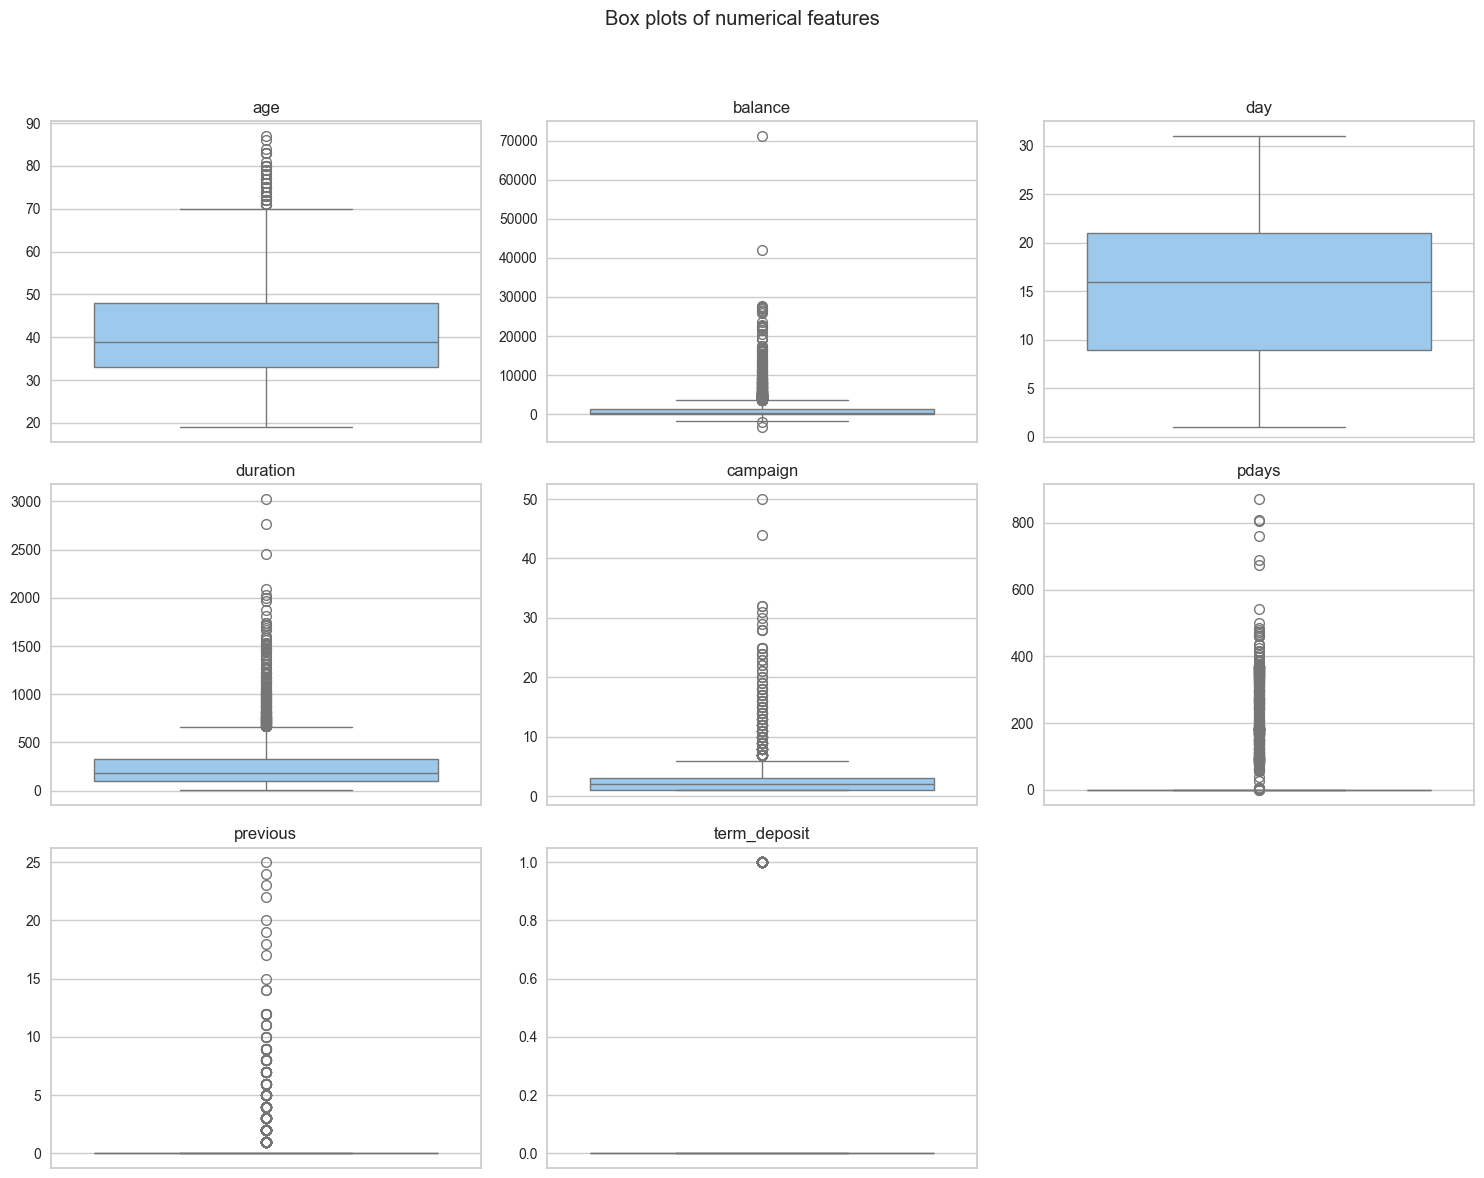

In [15]:
# Построим боксплоты для числовых фичей
cols = 3
rows = -(-len(numerical_features) // cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.boxplot(
        data=data_encoded,
        y=feature,
        color=colors[1],
        ax=axes[i]
    )
    axes[i].set_title(f'{feature}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Box plots of numerical features')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

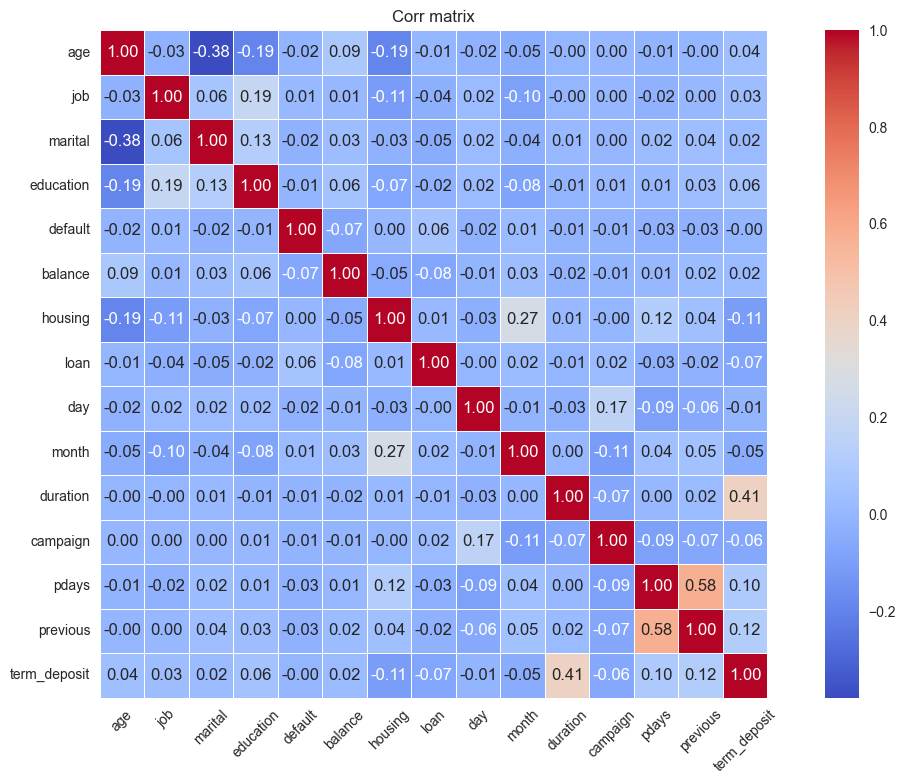

In [16]:
correlation_matrix = data_encoded.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    cbar=True,
    fmt=".2f",
    square=True,
    linewidths=0.5
)
plt.title('Corr matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 4) Подготовка данных для обучения

In [17]:
X=data_encoded.iloc[:,:-1]
y=data_encoded.iloc[:,-1]

In [18]:
# Примените случайную передискретизацию к матрице фичей X и целевой переменной y, чтобы устранить дисбаланс классов.
sm=RandomOverSampler()
X, y = sm.fit_resample(X, y)

In [19]:
# Нормализуем данные.
#sc = MinMaxScaler()
#X = sc.fit_transform(X)

In [20]:
# Разделим датасет на в следующих пропорциях train 70%, validation 15% and test 15%
X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid,
    test_size=0.1765,
    random_state=42,
    stratify=y_train_valid
)

print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'X_valid shape: {X_valid.shape}, y_valid shape: {y_valid.shape}')
print(f'X_test shape: {X_test.shape}, y_test shape: {y_test.shape}')

X_train shape: (5337, 14), y_train shape: (5337,)
X_valid shape: (1145, 14), y_valid shape: (1145,)
X_test shape: (1144, 14), y_test shape: (1144,)


# 3) Обучение модели

In [21]:
# Определяем словарь с нашими моделями
#models = {
#    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
#    'Random Forest': RandomForestClassifier(random_state=42),
#    'Decision Tree': DecisionTreeClassifier(random_state=42)
#}


=== Model: Logistic Regression ===
Fitting 5 folds for each of 31 candidates, totalling 155 fits
Best params: {'logisticregression__C': 0.1}
Best CV f1_macro: 0.78236


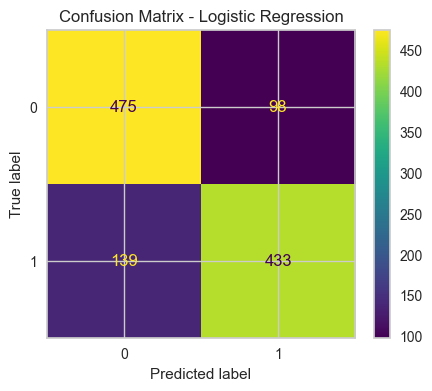

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.77      0.83      0.80       573
     Class 1       0.82      0.76      0.79       572

    accuracy                           0.79      1145
   macro avg       0.79      0.79      0.79      1145
weighted avg       0.79      0.79      0.79      1145


=== Model: Random Forest ===
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 400}
Best CV f1_macro: 0.87997


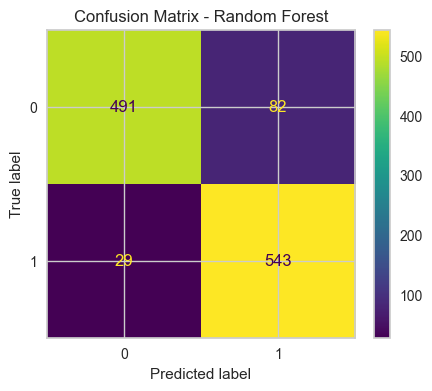

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.94      0.86      0.90       573
     Class 1       0.87      0.95      0.91       572

    accuracy                           0.90      1145
   macro avg       0.91      0.90      0.90      1145
weighted avg       0.91      0.90      0.90      1145


=== Model: Decision Tree ===
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'max_depth': 8, 'min_samples_leaf': 1}
Best CV f1_macro: 0.85313


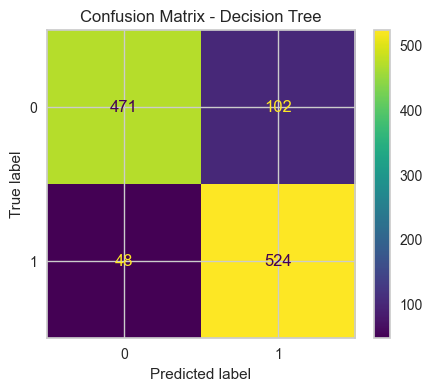

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.91      0.82      0.86       573
     Class 1       0.84      0.92      0.87       572

    accuracy                           0.87      1145
   macro avg       0.87      0.87      0.87      1145
weighted avg       0.87      0.87      0.87      1145


=== Model: Gradient Boosting ===
Fitting 5 folds for each of 400 candidates, totalling 2000 fits
Best params: {'learning_rate': 0.1, 'max_depth': 8, 'min_samples_leaf': 4, 'n_estimators': 500}
Best CV f1_macro: 0.96173


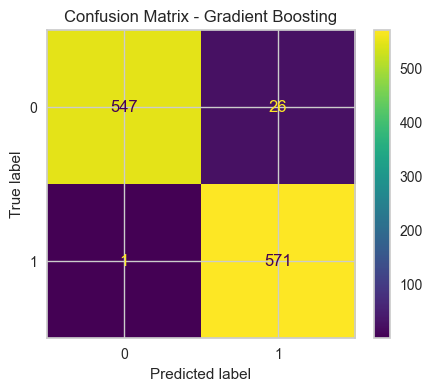

Classification Report:
              precision    recall  f1-score   support

     Class 0       1.00      0.95      0.98       573
     Class 1       0.96      1.00      0.98       572

    accuracy                           0.98      1145
   macro avg       0.98      0.98      0.98      1145
weighted avg       0.98      0.98      0.98      1145


=== Summary ===


,Model,Best Params,CV Best Score (f1_macro),Accuracy,Recall,F1 Score
0,Logistic Regression,{'logisticregression__C': 0.1},see printed above,0.793013,0.792982,0.792734
1,Random Forest,"{'max_depth': 8, 'min_samples_leaf': 1, 'n_est...",see printed above,0.903057,0.903097,0.902856
2,Decision Tree,"{'max_depth': 8, 'min_samples_leaf': 1}",see printed above,0.868996,0.869037,0.868714
3,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 8, 'min_sa...",see printed above,0.976419,0.976438,0.976409


              Model                                                                        Best Params CV Best Score (f1_macro)  Accuracy   Recall  F1 Score
Logistic Regression                                                     {'logisticregression__C': 0.1}        see printed above  0.793013 0.792982  0.792734
      Random Forest                       {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 400}        see printed above  0.903057 0.903097  0.902856
      Decision Tree                                            {'max_depth': 8, 'min_samples_leaf': 1}        see printed above  0.868996 0.869037  0.868714
  Gradient Boosting {'learning_rate': 0.1, 'max_depth': 8, 'min_samples_leaf': 4, 'n_estimators': 500}        see printed above  0.976419 0.976438  0.976409


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = 'f1_macro'

log_C_grid = [100, 90, 80, 70, 60, 50, 40, 30, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10,
              9, 8, 7, 6, 5, 4, 3, 2, 1, 0.1, 0.01, 0.001]

pipe_log = Pipeline([
    ('scaler', StandardScaler()),
    ('logisticregression', LogisticRegression(
        penalty='l2',
        solver='lbfgs',
        max_iter=1000,
        random_state=42
    ))
])


models = {
    'Logistic Regression': pipe_log,
    'Random Forest': RandomForestClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}


param_grids = {
    'Logistic Regression': {
        'logisticregression__C': log_C_grid
    },
    
    'Random Forest': {
        'n_estimators': [100, 200, 300, 400, 500],
        'max_depth': [4, 5, 6, 7, 8],
        'min_samples_leaf': [1, 2, 4, 8]
    },
    
    'Decision Tree': {
        'max_depth': [4, 5, 6, 7, 8],
        'min_samples_leaf': [1, 2, 4, 8]
    },
    
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300, 400, 500], 
        'learning_rate': [0.01, 0.02, 0.05, 0.1],
        'max_depth': [4, 5, 6, 7, 8],
        'min_samples_leaf': [1, 2, 4, 8]
    }
}

results = {'Model': [], 'Best Params': [], 'CV Best Score (f1_macro)': [], 'Accuracy': [], 'Recall': [], 'F1 Score': []}

for name, estimator in models.items():
    print(f"\n=== Model: {name} ===")
    grid = param_grids.get(name, None)
    if grid is None:
        print(f"Внимание: для модели {name} нет заданной сетки параметров — пропускаю GridSearch и просто обучаю модель.")
        model_to_fit = estimator
        model_to_fit.fit(X_train, y_train)
        best_est = model_to_fit
        best_params = {}
    else:
        # GridSearchCV
        gs = GridSearchCV(
            estimator,
            grid,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            verbose=1,
            refit=True
        )
        gs.fit(X_train, y_train)
        best_est = gs.best_estimator_
        best_params = gs.best_params_
        print("Best params:", best_params)
        print(f"Best CV {scoring}: {gs.best_score_:.5f}")

    # Предсказания на валидации
    y_pred = best_est.predict(X_valid)

    acc = accuracy_score(y_valid, y_pred)
    recall = recall_score(y_valid, y_pred, average='macro')
    f1 = f1_score(y_valid, y_pred, average='macro')

    results['Model'].append(name)
    results['Best Params'].append(best_params)
    results['CV Best Score (f1_macro)'].append(best_params and ('see printed above') or None)
    results['Accuracy'].append(acc)
    results['Recall'].append(recall)
    results['F1 Score'].append(f1)

    # Confusion matrix
    cm = confusion_matrix(y_valid, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax)
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

    classes = None
    try:
        classes = best_est.classes_
    except Exception:
        pass

    print("Classification Report:")
    print(classification_report(y_valid, y_pred, target_names=[f'Class {c}' for c in (classes if classes is not None else np.unique(y_valid))]))


results_df = pd.DataFrame(results)
print("\n=== Summary ===")
display(results_df)
print(results_df.to_string(index=False))



=== Model: Logistic Regression ===
Fitting 5 folds for each of 31 candidates, totalling 155 fits
Best params: {'logisticregression__C': 0.1}
Best CV f1_macro: 0.78236


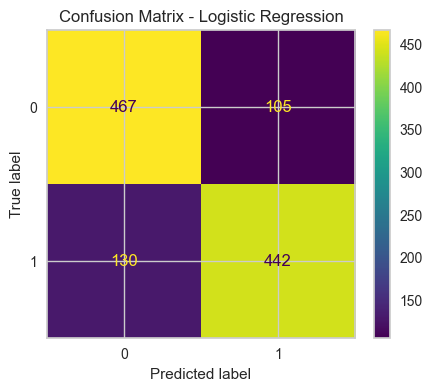

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.78      0.82      0.80       572
     Class 1       0.81      0.77      0.79       572

    accuracy                           0.79      1144
   macro avg       0.80      0.79      0.79      1144
weighted avg       0.80      0.79      0.79      1144


=== Model: Random Forest ===
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 400}
Best CV f1_macro: 0.87997


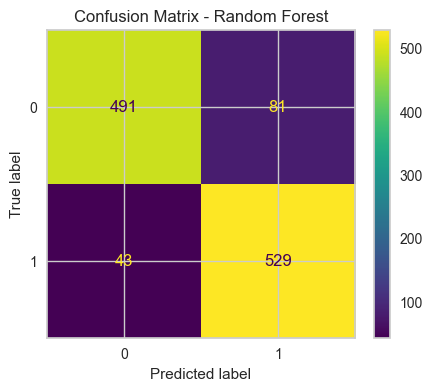

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.92      0.86      0.89       572
     Class 1       0.87      0.92      0.90       572

    accuracy                           0.89      1144
   macro avg       0.89      0.89      0.89      1144
weighted avg       0.89      0.89      0.89      1144


=== Model: Decision Tree ===
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'max_depth': 8, 'min_samples_leaf': 1}
Best CV f1_macro: 0.85313


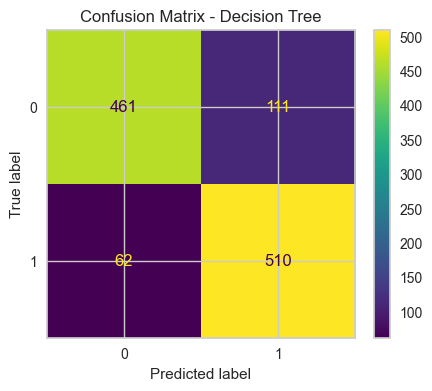

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.88      0.81      0.84       572
     Class 1       0.82      0.89      0.85       572

    accuracy                           0.85      1144
   macro avg       0.85      0.85      0.85      1144
weighted avg       0.85      0.85      0.85      1144


=== Model: Gradient Boosting ===
Fitting 5 folds for each of 400 candidates, totalling 2000 fits
Best params: {'learning_rate': 0.1, 'max_depth': 8, 'min_samples_leaf': 4, 'n_estimators': 500}
Best CV f1_macro: 0.96173


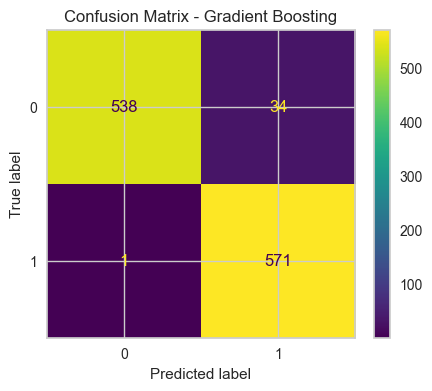

Classification Report:
              precision    recall  f1-score   support

     Class 0       1.00      0.94      0.97       572
     Class 1       0.94      1.00      0.97       572

    accuracy                           0.97      1144
   macro avg       0.97      0.97      0.97      1144
weighted avg       0.97      0.97      0.97      1144


=== Summary ===


,Model,Best Params,CV Best Score (f1_macro),Accuracy,Recall,F1 Score
0,Logistic Regression,{'logisticregression__C': 0.1},see printed above,0.794580,0.794580,0.794482
1,Random Forest,"{'max_depth': 8, 'min_samples_leaf': 1, 'n_est...",see printed above,0.891608,0.891608,0.891489
2,Decision Tree,"{'max_depth': 8, 'min_samples_leaf': 1}",see printed above,0.848776,0.848776,0.848498
3,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 8, 'min_sa...",see printed above,0.969406,0.969406,0.969380


              Model                                                                        Best Params CV Best Score (f1_macro)  Accuracy   Recall  F1 Score
Logistic Regression                                                     {'logisticregression__C': 0.1}        see printed above  0.794580 0.794580  0.794482
      Random Forest                       {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 400}        see printed above  0.891608 0.891608  0.891489
      Decision Tree                                            {'max_depth': 8, 'min_samples_leaf': 1}        see printed above  0.848776 0.848776  0.848498
  Gradient Boosting {'learning_rate': 0.1, 'max_depth': 8, 'min_samples_leaf': 4, 'n_estimators': 500}        see printed above  0.969406 0.969406  0.969380


In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = 'f1_macro'

log_C_grid = [100, 90, 80, 70, 60, 50, 40, 30, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10,
              9, 8, 7, 6, 5, 4, 3, 2, 1, 0.1, 0.01, 0.001]

pipe_log = Pipeline([
    ('scaler', StandardScaler()),
    ('logisticregression', LogisticRegression(
        penalty='l2',
        solver='lbfgs',
        max_iter=1000,
        random_state=42
    ))
])


models = {
    'Logistic Regression': pipe_log,
    'Random Forest': RandomForestClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}


param_grids = {
    'Logistic Regression': {
        'logisticregression__C': log_C_grid
    },
    
    'Random Forest': {
        'n_estimators': [100, 200, 300, 400, 500],
        'max_depth': [4, 5, 6, 7, 8],
        'min_samples_leaf': [1, 2, 4, 8]
    },
    
    'Decision Tree': {
        'max_depth': [4, 5, 6, 7, 8],
        'min_samples_leaf': [1, 2, 4, 8]
    },
    
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300, 400, 500], 
        'learning_rate': [0.01, 0.02, 0.05, 0.1],
        'max_depth': [4, 5, 6, 7, 8],
        'min_samples_leaf': [1, 2, 4, 8]
    }
}

results = {'Model': [], 'Best Params': [], 'CV Best Score (f1_macro)': [], 'Accuracy': [], 'Recall': [], 'F1 Score': []}

for name, estimator in models.items():
    print(f"\n=== Model: {name} ===")
    grid = param_grids.get(name, None)
    if grid is None:
        print(f"Внимание: для модели {name} нет заданной сетки параметров — пропускаю GridSearch и просто обучаю модель.")
        model_to_fit = estimator
        model_to_fit.fit(pd.concat([pd.DataFrame(X_train), pd.DataFrame(X_valid)]), pd.concat([y_train, y_valid]))
        best_est = model_to_fit
        best_params = {}
    else:
        # GridSearchCV
        gs = GridSearchCV(
            estimator,
            grid,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            verbose=1,
            refit=True
        )
        gs.fit(X_train, y_train)
        best_est = gs.best_estimator_
        best_params = gs.best_params_
        print("Best params:", best_params)
        print(f"Best CV {scoring}: {gs.best_score_:.5f}")

    # Предсказания на тесте
    y_pred = best_est.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    results['Model'].append(name)
    results['Best Params'].append(best_params)
    results['CV Best Score (f1_macro)'].append(best_params and ('see printed above') or None)
    results['Accuracy'].append(acc)
    results['Recall'].append(recall)
    results['F1 Score'].append(f1)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax)
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

    classes = None
    try:
        classes = best_est.classes_
    except Exception:
        pass

    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=[f'Class {c}' for c in (classes if classes is not None else np.unique(y_valid))]))


results_df = pd.DataFrame(results)
print("\n=== Summary ===")
display(results_df)
print(results_df.to_string(index=False))